all imports 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

Task 1 - Load and Understand the Dataset
● Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.
● Check the class distribution of is_canceled and use it as the target y.
● Create X from the remaining usable features. Identify numerical and categorical columns.

In [10]:
%pip install kagglehub

import pandas as pd

df = pd.read_csv(r"C:\Users\hasan pc\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1\hotel_bookings.csv")
print(df.shape)

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
print(path)

csv_file = os.path.join(path, "hotel_bookings.csv")
df = pd.read_csv(csv_file)

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.dtypes)

df = df.drop(columns=["reservation_status", "reservation_status_date", "company"])

print(df["is_canceled"].value_counts())
print(df["is_canceled"].value_counts(normalize=True) * 100)

y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("numerical columns:", num_cols)
print("categorical columns:", cat_cols)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
(119390, 32)
C:\Users\hasan pc\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1
(119390, 32)
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                    

C:\Users\hasan pc\AppData\Local\Temp\ipykernel_17872\3142000520.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


Task 2 - Missing Values, Leakage, and Outliers
● Find the missing-value count and percentage for every column.
● Identify columns with very high missingness. Drop them only if justified and state the reason.
● Remove columns that directly reveal the final booking outcome, such as reservation_status and
reservation_status_date.
● Check selected numerical features for outliers using boxplots and/or the IQR method.
● Remove only clear/extreme outliers and report how many rows were removed.

          missing_count  missing_pct
agent             16340    13.686238
country             488     0.408744
children              4     0.003350


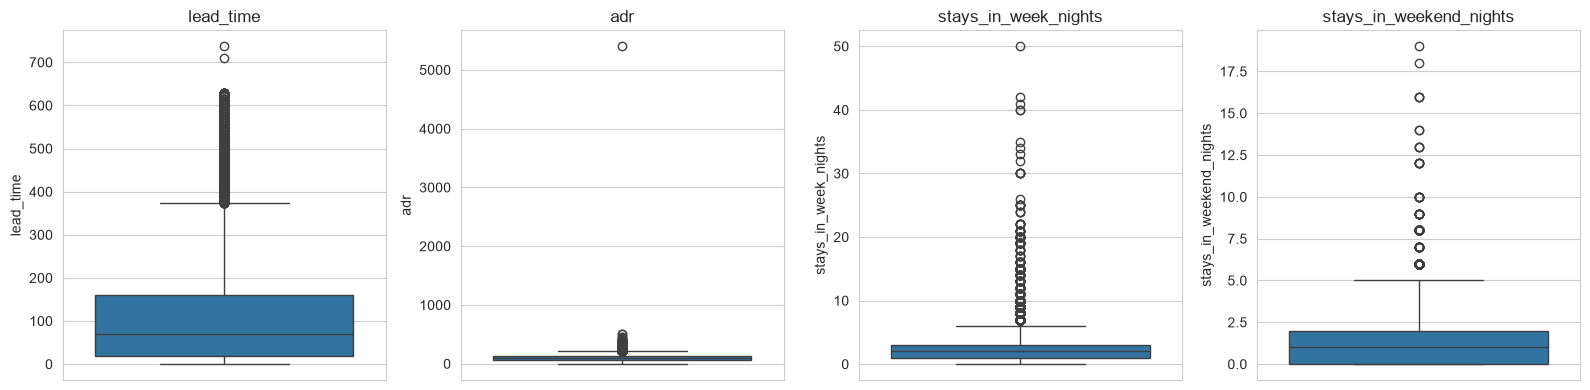

          adr
48515  5400.0
rows removed due to outliers: 328
(119062, 29)


In [11]:
import os
os.makedirs("figures", exist_ok=True)

# ---- Missing values ----
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print(missing_df)

# company already dropped earlier (was ~94% missing, unusable)
# agent has some missingness but is kept and imputed later
# country and children have very small missingness, also kept and imputed later

# ---- Outlier check ----
outlier_check_cols = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights"]

fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=X[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/outlier_boxplots.png", dpi=150)
plt.show()

# adr has a known extreme value (~5400) plus some negative/odd values
print(X[X["adr"] > 1000][["adr"]])

# remove only clear/extreme outliers in adr
rows_before = X.shape[0]
Q1 = X["adr"].quantile(0.25)
Q3 = X["adr"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR   # 3*IQR instead of 1.5 since adr naturally has a long right tail

mask = (X["adr"] <= upper_bound) & (X["adr"] >= 0)
X = X[mask]
y = y[mask]
rows_after = X.shape[0]
print(f"rows removed due to outliers: {rows_before - rows_after}")

# ---- Save cleaned base dataset ----
cleaned_df = X.copy()
cleaned_df["is_canceled"] = y
cleaned_df.to_csv("hotel_bookings_cleaned.csv", index=False)
print(cleaned_df.shape)

Task 3 - Create Two Preprocessing Pipelines
● Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for
all experiments.
● For numerical columns, use KNNImputer(n_neighbors=5) for missing values.
● For categorical columns, use SimpleImputer(strategy="most_frequent") and
OneHotEncoder(handle_unknown="ignore").
● Pipeline A: KNNImputer + StandardScaler for numerical features.
● Pipeline B: KNNImputer + MinMaxScaler for numerical features.
● Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

numeric_transformer_A = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

numeric_transformer_B = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer(transformers=[
    ("num", numeric_transformer_A, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

preprocessor_B = ColumnTransformer(transformers=[
    ("num", numeric_transformer_B, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

print(num_cols)
print(cat_cols)

(95249, 28) (23813, 28)
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


Part B - Model Training and Performance Evaluation
Task 4 - Train Two Classification Models
● Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.
● Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.
● Keep the model settings and train-test split unchanged across the comparison.
● You should obtain four trained model-pipeline combinations in total.

In [14]:
pipe_logreg_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipe_logreg_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipe_tree_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

pipe_tree_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

models = {
    "LogReg + Pipeline A (Standard)": pipe_logreg_A,
    "LogReg + Pipeline B (MinMax)": pipe_logreg_B,
    "Tree + Pipeline A (Standard)": pipe_tree_A,
    "Tree + Pipeline B (MinMax)": pipe_tree_B
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"{name} trained.")

LogReg + Pipeline A (Standard) trained.
LogReg + Pipeline B (MinMax) trained.
Tree + Pipeline A (Standard) trained.
Tree + Pipeline B (MinMax) trained.


Task 5 - Evaluate and Compare the Four Results
● For each experiment, calculate training accuracy, testing accuracy, precision, recall, and F1-score.
● Create a final comparison table containing all four model-pipeline combinations.
● Plot a confusion matrix for the best Logistic Regression result and the best Decision Tree result.
● Use the train-test performance difference to comment briefly on possible overfitting.

                            Model  Train Accuracy  Test Accuracy  Precision  \
0  LogReg + Pipeline A (Standard)          0.8177         0.8215     0.8137   
1    LogReg + Pipeline B (MinMax)          0.8134         0.8167     0.8099   
2    Tree + Pipeline A (Standard)          0.9961         0.8609     0.8105   
3      Tree + Pipeline B (MinMax)          0.9961         0.8608     0.8103   

   Recall  F1-score  Train-Test Gap  
0  0.6723    0.7363         -0.0038  
1  0.6601    0.7274         -0.0032  
2  0.8152    0.8128          0.1353  
3  0.8152    0.8127          0.1354  
Best Logistic Regression: LogReg + Pipeline A (Standard)
Best Decision Tree: Tree + Pipeline A (Standard)


AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_l'

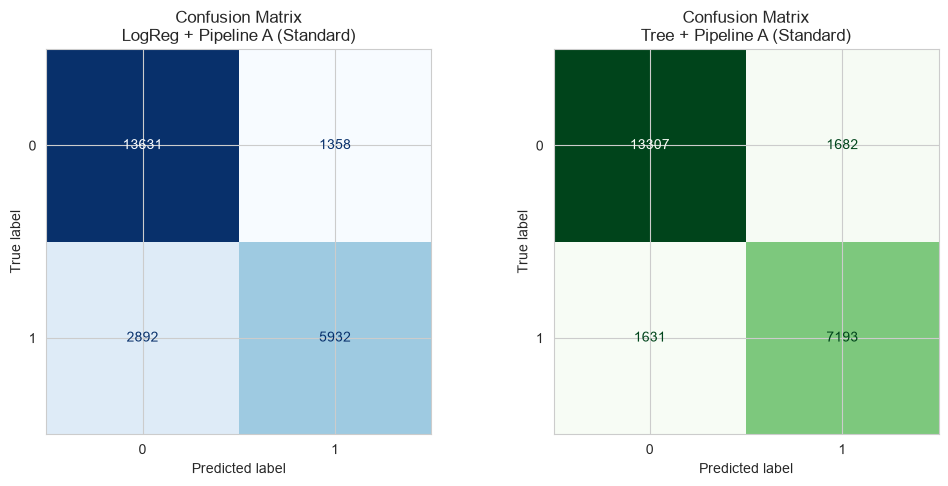

In [ ]:
results = []
predictions = {}

for name, pipe in models.items():
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    predictions[name] = test_pred

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-score": f1_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results)
results_df["Train-Test Gap"] = results_df["Train Accuracy"] - results_df["Test Accuracy"]
results_df = results_df.round(4)
print(results_df)
results_df.to_csv("model_comparison_results.csv", index=False)

# pick best logreg and best tree by F1, then plot confusion matrices
best_logreg = results_df[results_df["Model"].str.contains("LogReg")].sort_values("F1-score", ascending=False).iloc[0]["Model"]
best_tree = results_df[results_df["Model"].str.contains("Tree")].sort_values("F1-score", ascending=False).iloc[0]["Model"]
print("Best Logistic Regression:", best_logreg)
print("Best Decision Tree:", best_tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_logreg = confusion_matrix(y_test, predictions[best_logreg])
ConfusionMatrixDisplay(cm_logreg).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix\n{best_logreg}")

cm_tree = confusion_matrix(y_test, predictions[best_tree])
ConfusionMatrixDisplay(cm_tree).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Confusion Matrix\n{best_tree}")


Task 6 - Final Observations
● Which preprocessing-model combination gives the best overall result?
● Does StandardScaler or MinMaxScaler affect Logistic Regression more?
● Does scaling make a major difference for the Decision Tree? Comment briefly.
● Write 4-5 short observations supported by the performance table and confusion matrices.